<a href="https://colab.research.google.com/github/Gajalakshmi993/Diamond_price_prediction/blob/main/Diamond_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

file_path = r"/content/drive/MyDrive/Diamond_dataset/Diamond_cleaned.csv"
data = pd.read_csv(file_path)
data.head()

,carat,cut,color,clarity,Total_depth_Percentage,table,price,Length,Width,Depth
0,0.23,Ideal,E,SI2,61.50,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.80,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,58.75,63.5,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.40,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.30,58.0,335,4.34,4.35,2.75


In [ ]:
data.shape

(53940, 10)

In [ ]:
data.select_dtypes(include=['object']).columns

Index(['cut', 'color', 'clarity'], dtype='object')

In [ ]:
data["cut"].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [ ]:
data["color"].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [ ]:
data["clarity"].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

##Encoder

In [ ]:
cut = ['Premium', 'Ideal', 'Very Good', 'Good', 'Fair']

# Define Encoder with Custom Order
ordinal_encoder = OrdinalEncoder(categories=[cut])

# Fit and Transform
data['cut'] = ordinal_encoder.fit_transform(data[['cut']])

data['cut'] = data['cut'].astype(int)

In [ ]:
data["cut"].unique()

array([1, 0, 3, 2, 4])

In [ ]:
color = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

# Define Encoder with Custom Order
ordinal_encoder = OrdinalEncoder(categories=[color])

# Fit and Transform
data['color'] = ordinal_encoder.fit_transform(data[['color']])

data['color'] = data['color'].astype(int)

In [ ]:
data["color"].unique()

array([1, 5, 6, 4, 2, 3, 0])

In [ ]:
clarity = ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']

le = LabelEncoder()
data['clarity'] = le.fit_transform(data['clarity'])

In [ ]:
data['clarity'].unique()

array([3, 2, 4, 5, 7, 6, 0, 1])

In [ ]:
continuous=['price', 'carat', 'Length', 'Width', 'Depth']

##Skewness

In [ ]:
skew_values = data[continuous].skew()

print(skew_values)

price     1.618395
carat     0.899893
Length    0.394179
Width     0.389861
Depth     0.387198
dtype: float64


In [ ]:
Kurtosis_values = data[continuous].kurtosis()

In [ ]:
print(Kurtosis_values)

price     2.177696
carat     0.111667
Length   -0.723182
Width    -0.730902
Depth    -0.727169
dtype: float64


In [ ]:
high_skew = skew_values[abs(skew_values) > 0.5]

print("Highly skewed features:\n", high_skew)

Highly skewed features:
 price    1.618395
carat    0.899893
dtype: float64


In [ ]:
import numpy as np
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

# Step 1: Skewness check
skew_vals = data[continuous].skew()
print("Skewness Before:\n", skew_vals)

# Step 2: Log transform highly skewed ones
data['price_log'] = np.log1p(data['price'])
data['carat_log'] = np.log1p(data['carat'])

# Step 4: Check skewness again
new_skew = data[['price_log', 'carat_log']].skew()
print("\nSkewness After:\n", new_skew)

Skewness Before:
 price     1.618395
carat     0.899893
Length    0.394179
Width     0.389861
Depth     0.387198
dtype: float64

Skewness After:
 price_log    0.115926
carat_log    0.494919
dtype: float64


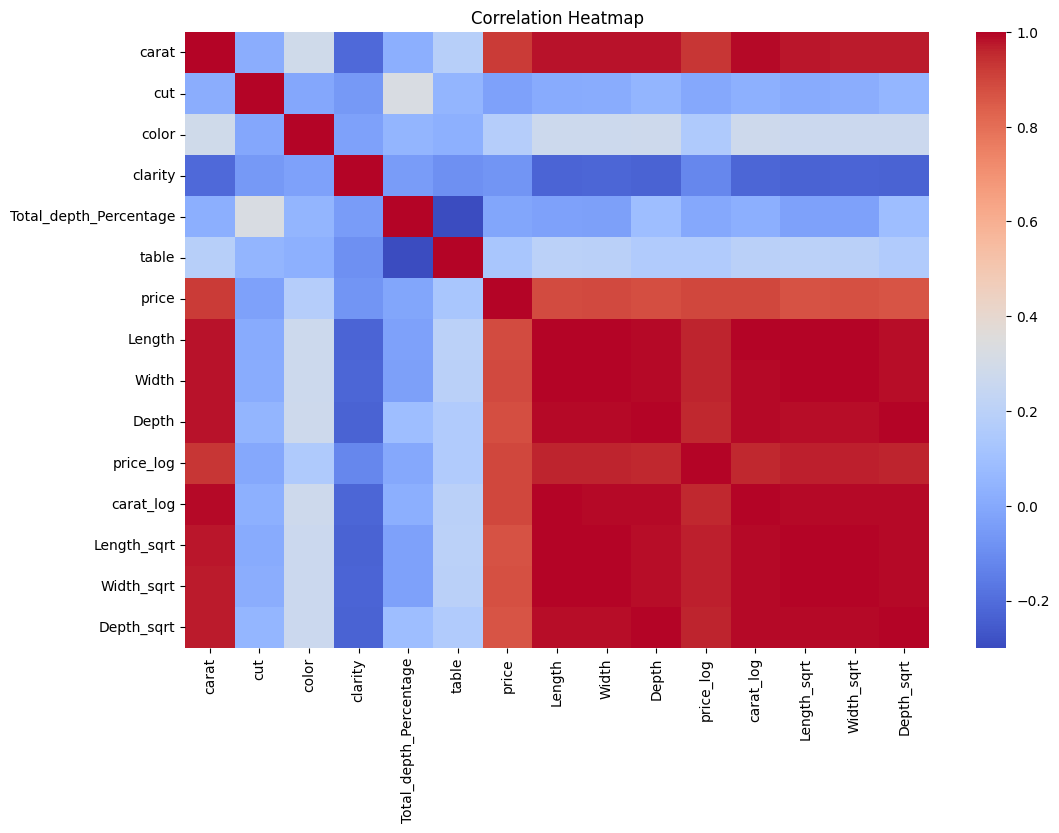

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
data.corr()

,carat,cut,color,clarity,Total_depth_Percentage,table,price,Length,Width,Depth,price_log,carat_log,Length_sqrt,Width_sqrt,Depth_sqrt
carat,1.000000,0.019527,0.289054,-0.213409,0.021868,0.187523,0.922484,0.983099,0.982231,0.981047,0.933204,0.992130,0.974650,0.973815,0.972426
cut,0.019527,1.000000,-0.007638,-0.056788,0.329634,0.046950,-0.028843,0.005342,0.014925,0.048307,-0.001556,0.027810,0.008820,0.018348,0.050589
color,0.289054,-0.007638,1.000000,-0.027795,0.047227,0.027117,0.172511,0.270695,0.270413,0.274733,0.155010,0.277604,0.264422,0.264214,0.268553
clarity,-0.213409,-0.056788,-0.027795,1.000000,-0.048162,-0.089735,-0.071535,-0.225920,-0.222963,-0.229468,-0.120025,-0.223189,-0.228877,-0.225926,-0.232241
Total_depth_Percentage,0.021868,0.329634,0.047227,-0.048162,1.000000,-0.299886,-0.012521,-0.028712,-0.031418,0.089984,-0.001122,0.024206,-0.027079,-0.029807,0.089693
table,0.187523,0.046950,0.027117,-0.089735,-0.299886,1.000000,0.130391,0.198717,0.192795,0.158932,0.161239,0.193487,0.199281,0.193334,0.159539
price,0.922484,-0.028843,0.172511,-0.071535,-0.012521,0.130391,1.000000,0.887003,0.888475,0.881359,0.895856,0.898338,0.872597,0.873950,0.867156
Length,0.983099,0.005342,0.270695,-0.225920,-0.028712,0.198717,0.887003,1.000000,0.998514,0.990593,0.960827,0.995347,0.998825,0.997322,0.989472
Width,0.982231,0.014925,0.270413,-0.222963,-0.031418,0.192795,0.888475,0.998514,1.000000,0.990336,0.961474,0.994664,0.997433,0.998845,0.989282
Depth,0.981047,0.048307,0.274733,-0.229468,0.089984,0.158932,0.881359,0.990593,0.990336,1.000000,0.956575,0.993606,0.989828,0.989517,0.998816
